# PIM / VLOOP / TCOST — cross-venue LOP gap

**Paper:** §2 Eqs 1–3 (PDF pp. 8–12) · **NOTES:** [`NOTES.md`](NOTES.md) · **EXP:** [`EXP_REPORT.md`](EXP_REPORT.md)  
**Artifacts:** `out/pim_vloop_tcost/` · **Lib:** `research.lib.cdme`

$$\mathrm{PIM}_t = \mathbb{E}_t[\mathrm{VLOOP}_t + |\mathrm{TCOST}_t| \mid \mathrm{VLOOP}_t > 0]$$

Desk: **HL + Deribit** real quotes on ETH (certified `panel_core_2venue` **n=9**). Kraken = dense **spot_l2** only (n=4 subpanel); `trade_synth` **QUARANTINED**. Detection ≠ executable arb → **Kill** `alpha.tob_cross_arb`.


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / "research" / "books" / "cd_me"
OUT = BOOK / "out"
SCRIPTS = BOOK / "scripts"
ROOT = BOOK.parents[2]  # ares-microstructure repo root (research.lib absolute imports)
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(ROOT))
from _nb_common import (
    load_json, expand_pim_hourly, expand_dcm_hourly, day_summary_table, SIGNAL_BOARD,
    load_kraken_inventory, kraken_mode_for_day,
)
from certified_panel import load_certified, primary_days, spot_l2_days
from research.lib import cdme  # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def show_pngs(fig_dir: Path, pattern="*.png"):
    if not fig_dir.is_dir():
        print("no figs dir", fig_dir)
        return
    for p in sorted(fig_dir.glob(pattern)):
        display(Markdown(f"**{p.name}** — `{p.relative_to(BOOK)}`"))
        display(Image(filename=str(p)))

def print_board(rows=None):
    rows = rows or SIGNAL_BOARD
    print(f"{'id':34s} {'gate':6s} note")
    print("-" * 88)
    for i, g, n in rows:
        print(f"{i:34s} {g:6s} {n}")

PASS2 = OUT / "pass2"
KR_INV = load_kraken_inventory(BOOK)
CERT = load_certified()
PRIMARY = primary_days(CERT)
SPOT = spot_l2_days(CERT)
print("BOOK", BOOK)
print("certified primary n=", len(PRIMARY), PRIMARY)
print("spot_l2 subpanel n=", len(SPOT), SPOT)
print("pass2 present", PASS2.is_dir(), "falsifiers", (PASS2 / "pass2_falsifiers.json").is_file())
print("trade_synth QUARANTINED — never primary")


BOOK /home/dev/srv/ares-microstructure/research/books/cd_me
certified primary n= 9 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
spot_l2 subpanel n= 4 ['2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
pass2 present True falsifiers True
trade_synth QUARANTINED — never primary


In [2]:

summary = load_json(OUT / "pim_vloop_tcost" / "summary.json")
panel = load_json(OUT / "pim_vloop_tcost" / "panel_rows.json") or []
hourly = expand_pim_hourly(panel)
tbl = day_summary_table(panel, inventory=KR_INV)
print(json.dumps({k: summary.get(k) for k in ("ok","symbol","days","n_ok","venues","dt_s","bucket_s","honesty")} if summary else {}, indent=2))
display(tbl.round(5))
print("hourly rows", len(hourly), "finite PIM", int(np.isfinite(hourly["pim"]).sum()))
print("kraken modes:", tbl["kraken"].value_counts().to_dict())


{
  "ok": true,
  "symbol": "ETH",
  "days": [
    "2026-09-14",
    "2026-09-15",
    "2026-09-16",
    "2026-09-17",
    "2026-09-18",
    "2026-09-25",
    "2026-09-26",
    "2026-09-27",
    "2026-10-01"
  ],
  "n_ok": 9,
  "venues": [
    "hyperliquid",
    "deribit",
    "kraken"
  ],
  "dt_s": 5.0,
  "bucket_s": 3600.0,
  "honesty": "PIM on real quotes only (HL\u2194Deribit; Kraken spot_l2 optional). trade_synth QUARANTINED \u2014 never Promote TOB-cross as arb \u03b1"
}


,day,ok,venues,n_venues,n_finite,pim_mean,vloop_mean,tcost_mean,corr_vt,cov_hl,cov_db,cov_kr,kraken
0,2026-09-14,True,"hyperliquid,deribit",2,668,0.01558,0.00699,0.00435,0.83078,0.04253,0.49326,NaN,absent_2venue
1,2026-09-15,True,"hyperliquid,deribit",2,165,0.02103,0.01091,0.00300,0.99998,0.04375,0.49008,NaN,absent_2venue
2,2026-09-16,True,"hyperliquid,deribit",2,621,0.01183,0.00613,0.00394,0.99379,0.04271,0.47306,NaN,absent_2venue
3,2026-09-17,True,"hyperliquid,deribit",2,582,0.01237,0.00605,0.00328,0.94280,0.04271,0.49644,NaN,absent_2venue
4,2026-09-18,True,"hyperliquid,deribit",2,717,0.01327,0.00696,0.00448,0.99460,0.04392,0.48510,NaN,absent_2venue
5,2026-09-25,True,"hyperliquid,deribit,kraken",3,1876,0.02822,0.01394,0.00519,0.90898,0.04305,0.48452,0.09820,spot_l2
6,2026-09-26,True,"hyperliquid,deribit,kraken",3,1863,0.03570,0.01793,0.00898,0.90200,0.04340,0.49962,0.12522,spot_l2
7,2026-09-27,True,"hyperliquid,deribit,kraken",3,914,0.03210,0.01534,0.00837,0.84475,0.04340,0.49991,0.01123,spot_l2
8,2026-10-01,True,"hyperliquid,deribit,kraken",3,1502,0.04689,0.02324,0.00712,0.90977,0.04375,0.40241,0.05706,spot_l2


hourly rows 225 finite PIM 98
kraken modes: {'absent_2venue': 5, 'spot_l2': 4}


## Existing Pass-2 figures


**fig_pim_day_means.png** — `out/pim_vloop_tcost/figs/fig_pim_day_means.png`

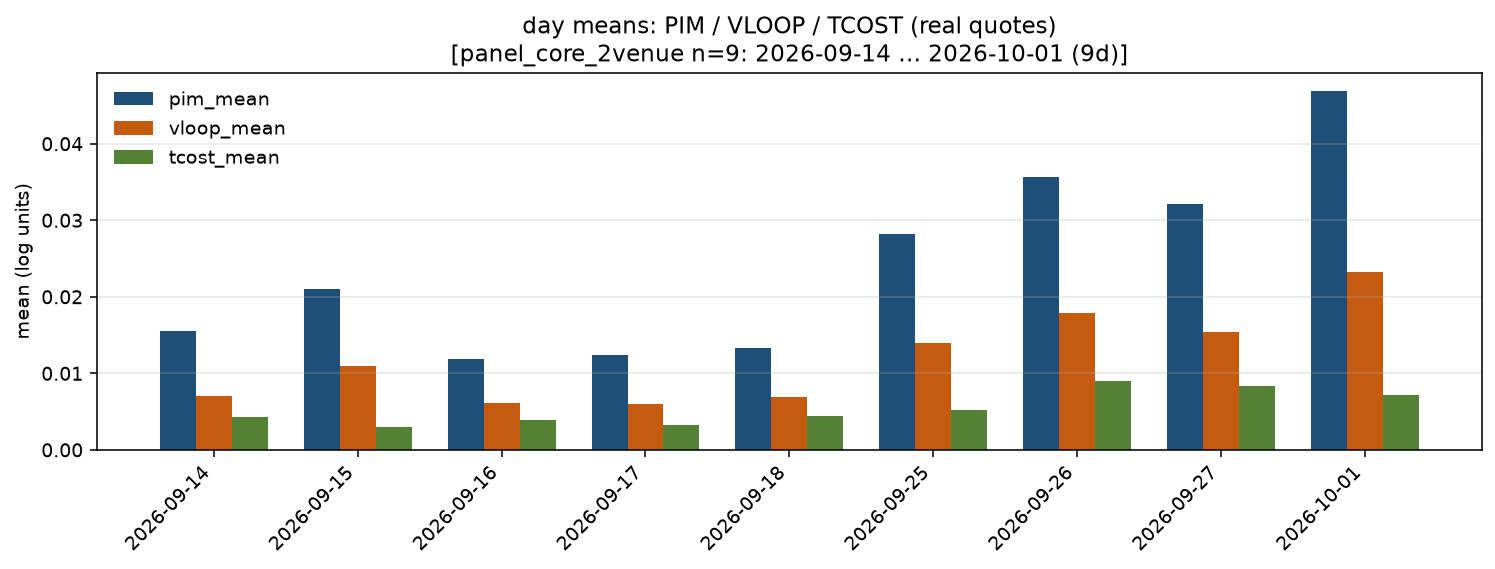

**fig_pim_hourly.png** — `out/pim_vloop_tcost/figs/fig_pim_hourly.png`

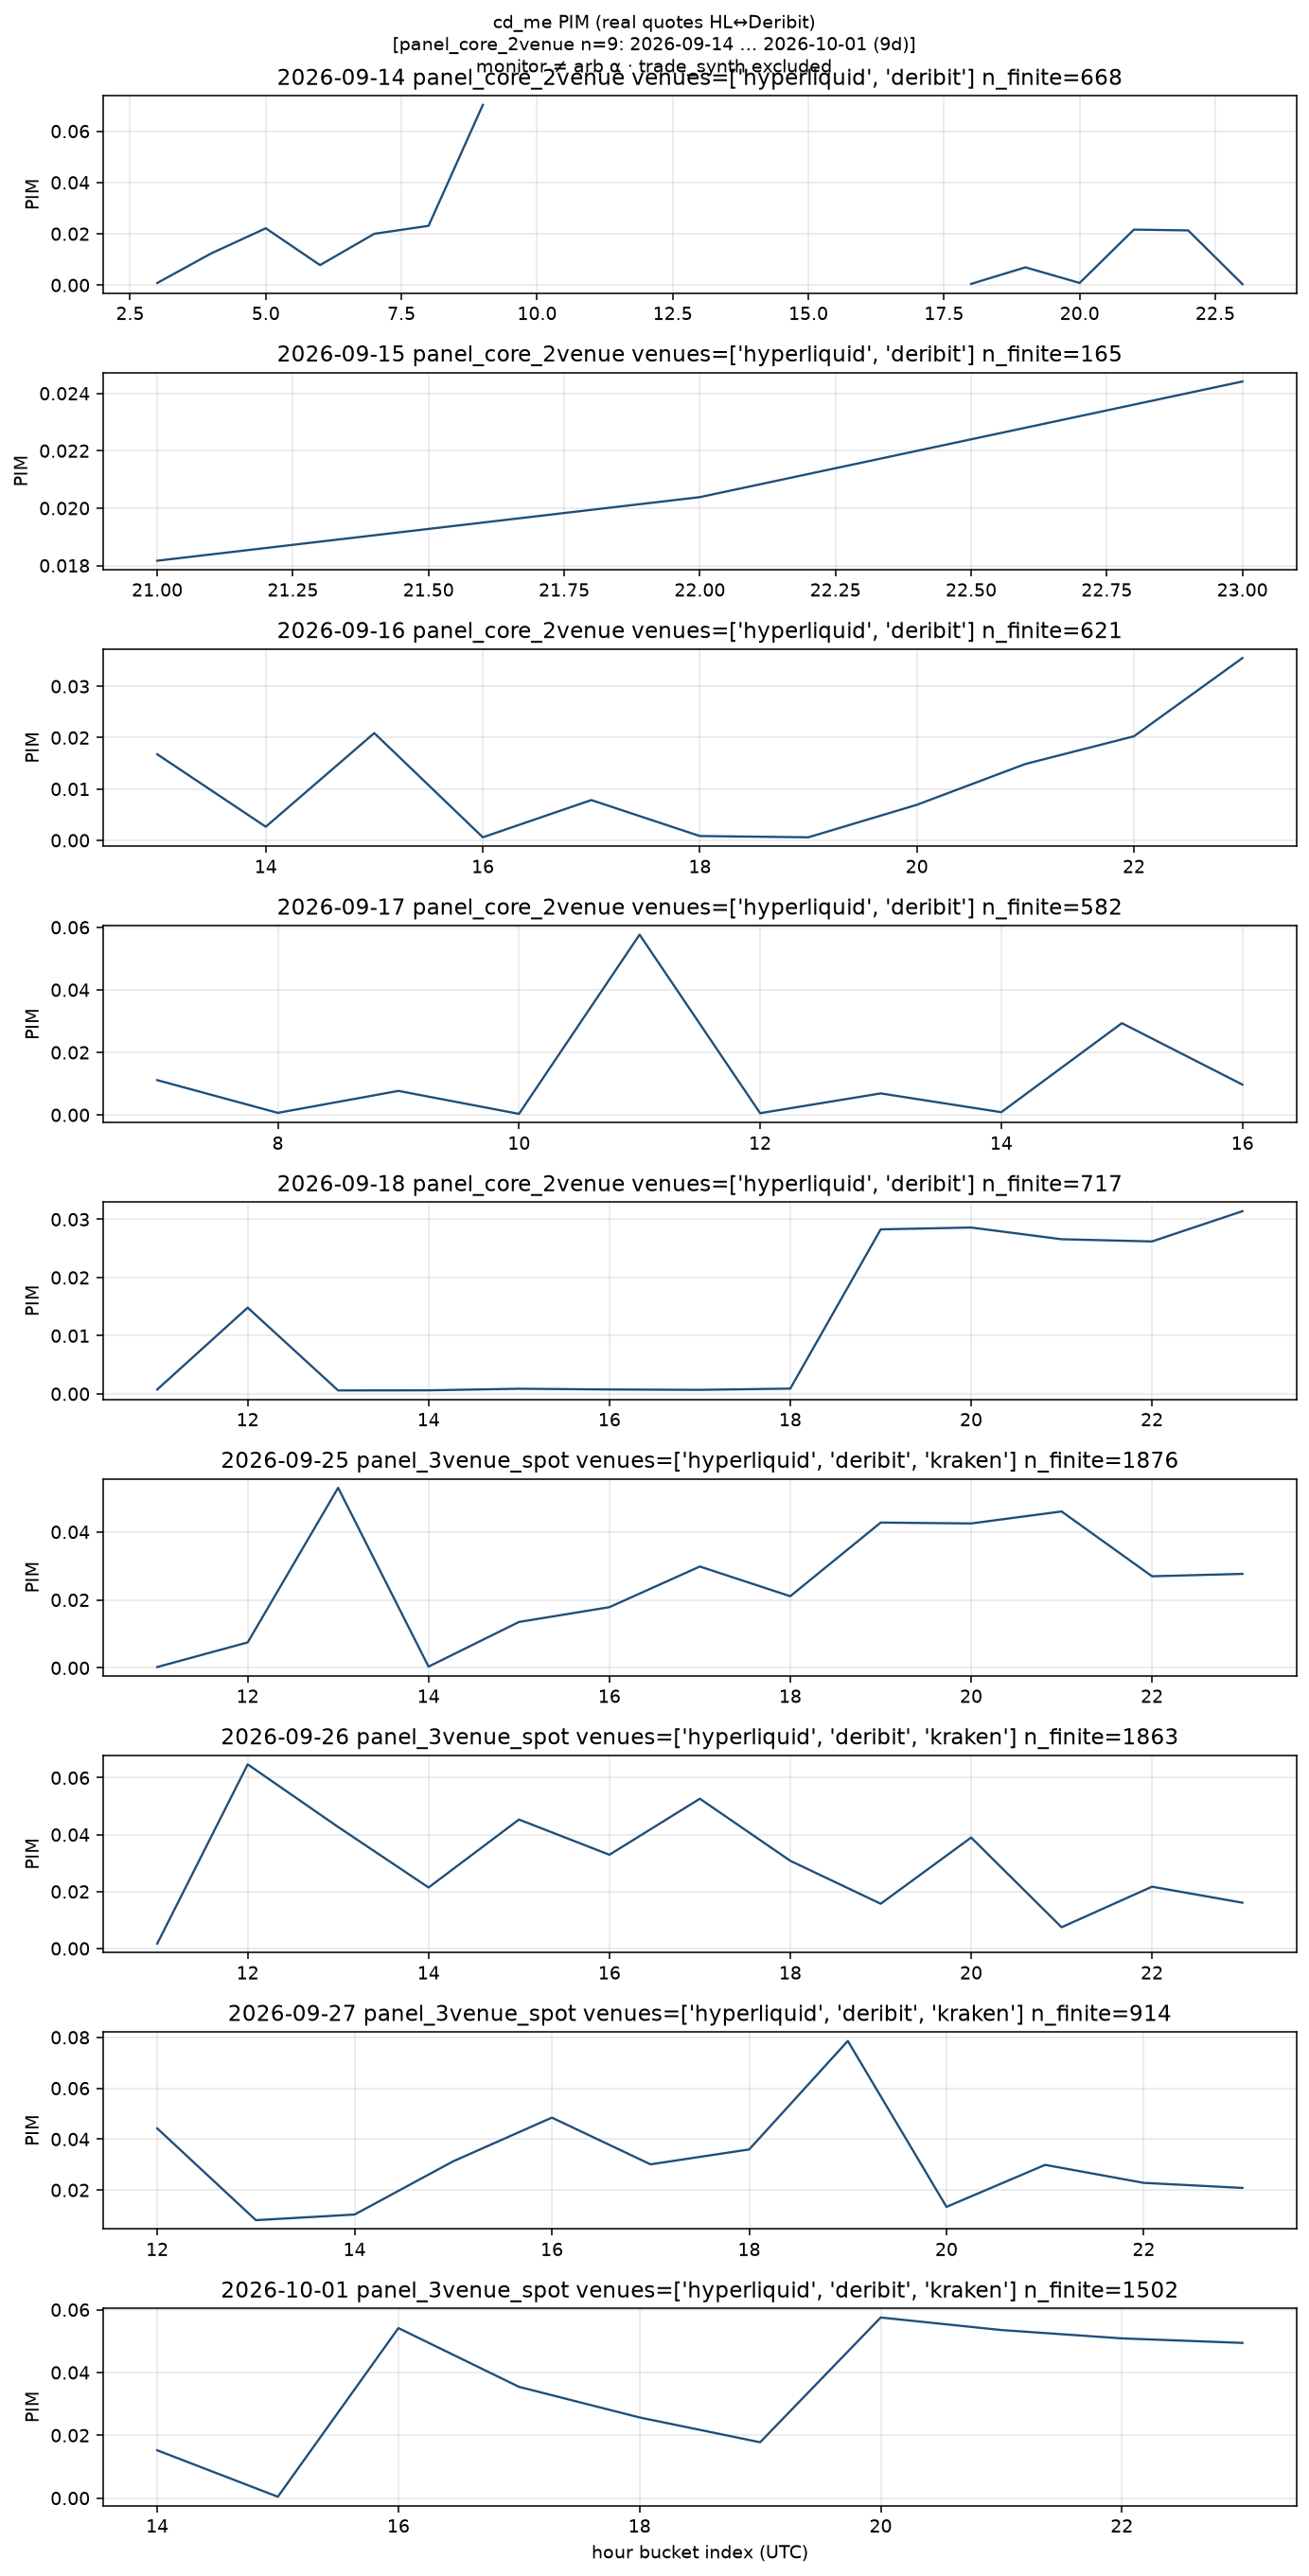

**fig_vloop_tcost_corr.png** — `out/pim_vloop_tcost/figs/fig_vloop_tcost_corr.png`

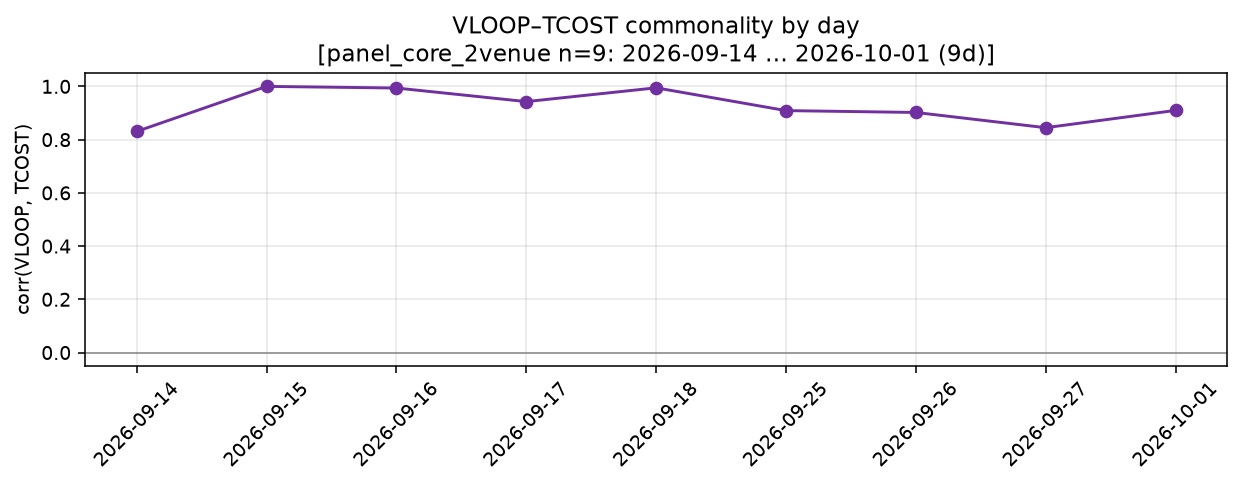

In [3]:
show_pngs(OUT / "pim_vloop_tcost" / "figs")


## Expansion — time-of-day + day panel

Hourly PIM means by UTC hour (pooled) and a day×hour heatmap. Sparse TOB → many NaNs; interpret as research-grade coverage, not HFT. Primary plots use certified real-quote days only (`has_synth=false`).


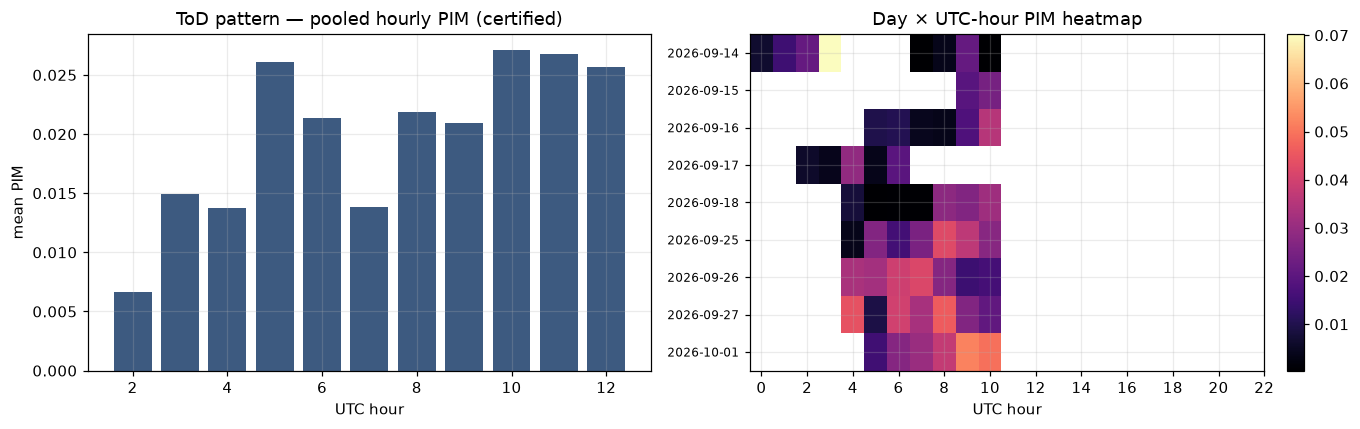

 hour_utc    mean  count
        0     NaN      0
        1     NaN      0
        2 0.00662      2
        3 0.01496      2
        4 0.01372      4
        5 0.02608      3
        6 0.02135      9
        7 0.01381     13
        8 0.02186     14
        9 0.02094     13
       10 0.02709     14
       11 0.02679     16
       12 0.02571      8


In [4]:

h = hourly.copy()
tod = h.groupby("hour_utc")["pim"].agg(["mean", "count"]).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
ax = axes[0]
ax.bar(tod["hour_utc"], tod["mean"], color="#3d5a80")
ax.set_xlabel("UTC hour"); ax.set_ylabel("mean PIM"); ax.set_title("ToD pattern — pooled hourly PIM (certified)")
# heatmap
pivot = h.pivot_table(index="day", columns="hour_utc", values="pim", aggfunc="mean")
ax = axes[1]
im = ax.imshow(pivot.values, aspect="auto", cmap="magma", interpolation="nearest")
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(list(pivot.index), fontsize=8)
ax.set_xticks(range(0, 24, 2)); ax.set_xticklabels(list(range(0, 24, 2)))
ax.set_title("Day × UTC-hour PIM heatmap")
ax.set_xlabel("UTC hour")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()
print(tod.round(5).to_string(index=False))


## Expansion — VLOOP vs TCOST scatter + stress split


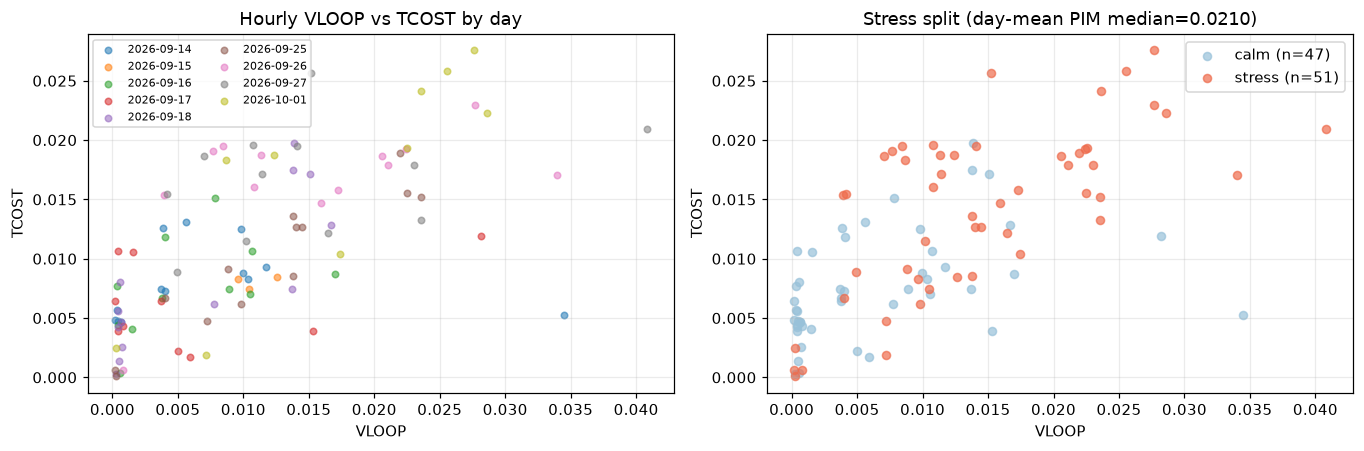

pooled corr(VLOOP,TCOST)=0.667 n=98
          vloop    tcost      pim
stress                           
calm    0.00652  0.00762  0.01322
stress  0.01459  0.01443  0.02977


In [5]:

ok = h[np.isfinite(h["vloop"]) & np.isfinite(h["tcost"])].copy()
# stress = days with above-median day-mean PIM
day_means = ok.groupby("day")["pim"].mean()
med = float(day_means.median()) if len(day_means) else np.nan
ok["stress"] = ok["day"].map(lambda d: "stress" if day_means.get(d, 0) >= med else "calm")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
for name, g in ok.groupby("day"):
    ax.scatter(g["vloop"], g["tcost"], s=18, alpha=0.55, label=name)
ax.set_xlabel("VLOOP"); ax.set_ylabel("TCOST"); ax.set_title("Hourly VLOOP vs TCOST by day")
ax.legend(fontsize=7, ncol=2, framealpha=0.8)

ax = axes[1]
for lab, color in (("calm", "#98c1d9"), ("stress", "#ee6c4d")):
    g = ok[ok["stress"] == lab]
    ax.scatter(g["vloop"], g["tcost"], s=28, alpha=0.7, c=color, label=f"{lab} (n={len(g)})")
ax.set_xlabel("VLOOP"); ax.set_ylabel("TCOST"); ax.set_title(f"Stress split (day-mean PIM median={med:.4f})")
ax.legend()
plt.tight_layout(); plt.show()

corr_all = ok["vloop"].corr(ok["tcost"])
print(f"pooled corr(VLOOP,TCOST)={corr_all:.3f} n={len(ok)}")
print(ok.groupby("stress")[["vloop","tcost","pim"]].mean().round(5))


## Coverage honesty (HL / Deribit / Kraken spot_l2 vs absent_2venue)


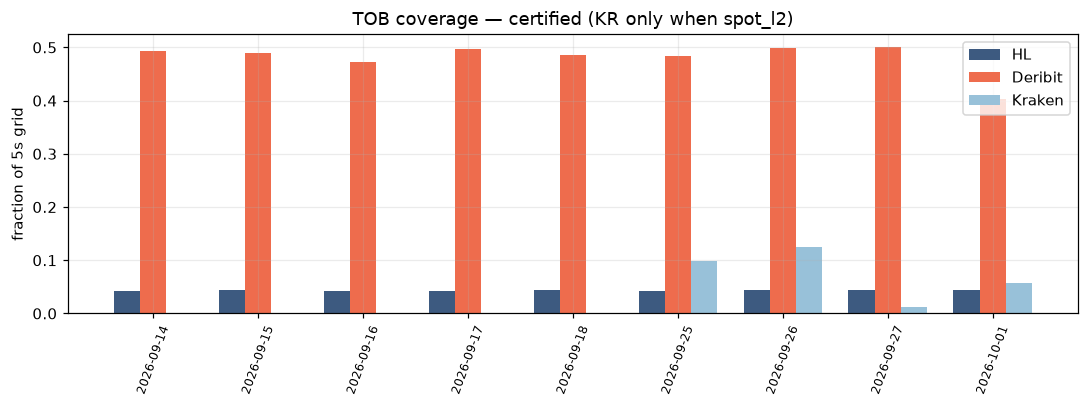

       day                     venues        kraken   cov_kr
2026-09-14        hyperliquid,deribit absent_2venue      NaN
2026-09-15        hyperliquid,deribit absent_2venue      NaN
2026-09-16        hyperliquid,deribit absent_2venue      NaN
2026-09-17        hyperliquid,deribit absent_2venue      NaN
2026-09-18        hyperliquid,deribit absent_2venue      NaN
2026-09-25 hyperliquid,deribit,kraken       spot_l2 0.098200
2026-09-26 hyperliquid,deribit,kraken       spot_l2 0.125224
2026-09-27 hyperliquid,deribit,kraken       spot_l2 0.011226
2026-10-01 hyperliquid,deribit,kraken       spot_l2 0.057057
  2026-09-14: mode=PROXY_NOT_TOB_trade_synth | spot-000 (L2 present; rebuild n≈1)
  2026-09-15: mode=PROXY_NOT_TOB_trade_synth | spot-000 (L2 present; rebuild n≈1)
  2026-09-16: mode=PROXY_NOT_TOB_trade_synth | spot-000 (L2 present; rebuild n≈1)
  2026-09-17: mode=PROXY_NOT_TOB_trade_synth | spot-000 (L2 present; rebuild n≈1)
  2026-09-18: mode=PROXY_NOT_TOB_trade_synth | futures-000 onl

In [6]:

fig, ax = plt.subplots(figsize=(10.0, 3.8))
x = np.arange(len(tbl))
w = 0.25
ax.bar(x - w, tbl["cov_hl"].fillna(0), w, label="HL", color="#3d5a80")
ax.bar(x, tbl["cov_db"].fillna(0), w, label="Deribit", color="#ee6c4d")
ax.bar(x + w, tbl["cov_kr"].fillna(0), w, label="Kraken", color="#98c1d9")
ax.set_xticks(x); ax.set_xticklabels(tbl["day"], rotation=70, fontsize=8)
ax.set_ylabel("fraction of 5s grid")
ax.set_title("TOB coverage — certified (KR only when spot_l2)")
ax.legend()
plt.tight_layout(); plt.show()
print(tbl[["day", "venues", "kraken", "cov_kr"]].to_string(index=False))
inv_streams = (KR_INV or {}).get("streams_by_panel_day") or {}
for day, note in inv_streams.items():
    print(f"  {day}: mode={kraken_mode_for_day(day, KR_INV)} | {note}")
if summary:
    ks = summary.get("kraken_status") or []
    print("kraken_status in_tob days", sum(1 for r in ks if r.get("in_tob")), "/", len(ks))


## Lib smoke (synthetic) — formulas still compute without warehouse


In [7]:

# cheap synthetic check of paper objects (not a backtest)
rng = np.random.default_rng(0)
mid_a = 3000 + np.cumsum(rng.normal(0, 0.5, 500))
mid_b = mid_a * np.exp(rng.normal(0, 0.0004, 500))
v = cdme.vloop_pair(mid_a, mid_b)
hs_a = np.full_like(mid_a, 0.0002); hs_b = np.full_like(mid_b, 0.0003)
tc = cdme.tcost_from_spreads({"a": hs_a, "b": hs_b})
pim = cdme.pim_from_components(v, tc)
print("synthetic mean VLOOP/TCOST/PIM", float(np.nanmean(v)), float(np.nanmean(tc)), float(np.nanmean(pim)))


synthetic mean VLOOP/TCOST/PIM 0.00029819089921386785 0.0005000000000000002 0.000798190899213868


## Signal board + falsifier status


In [8]:

print_board([
    ("risk.pim_cross_venue", "Hold", "n=9 panel_core_2venue; spot_l2 subpanel n=4; synth QUARANTINED"),
    ("info.vloop_tcost_commonality", "Hold", "strong corr on finite hours"),
    ("alpha.tob_cross_arb", "Kill", "detection ≠ sized arb; trade_synth PROXY never Promote"),
])
p2 = load_json(PASS2 / "pass2_falsifiers.json") if PASS2.is_dir() else None
if p2:
    print("pass2 pim_panel:", {k: (p2.get("pim_panel") or {}).get(k)
          for k in ("n_days_ok", "n_days_3_venue_tob", "n_days_kraken_tob", "vloop_tcost_corr_median")})
    print("pass2 decisions:", p2.get("decisions"))
else:
    print("pass2/ not present — run scripts/exp_pass2_falsifiers.py")


id                                 gate   note
----------------------------------------------------------------------------------------
risk.pim_cross_venue               Hold   n=9 panel_core_2venue; spot_l2 subpanel n=4; synth QUARANTINED
info.vloop_tcost_commonality       Hold   strong corr on finite hours
alpha.tob_cross_arb                Kill   detection ≠ sized arb; trade_synth PROXY never Promote
pass2 pim_panel: {'n_days_ok': 9, 'n_days_3_venue_tob': 0, 'n_days_kraken_tob': 0, 'vloop_tcost_corr_median': 0.9427958847810103}
pass2 decisions: {'risk.pim_cross_venue': 'Hold', 'info.vloop_tcost_commonality': 'Hold', 'risk.dcm_pc1': 'Hold', 'liq.elasticity_regime': 'Hold', 'promote_count': 0, 'note': 'Pass-2 falsifiers run; 0 Promote — monitors only, no TOB-cross α'}
